# 07 - Baseline Comparison: SA-PINN & RAR-PINN vs AC-PINN
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

Benchmarks two published baseline methods against our AC-PINN, all on
Burgers' equation under noisy sparse data (the hardest condition, same
as the ablation study).

| Model | Loss weighting | Collocation points |
|---|---|---|
| Vanilla PINN | fixed | fixed, uniform |
| SA-PINN (Wang et al. 2022) | learned via softmax + gradient ascent | fixed, uniform |
| RAR-PINN (Lu et al. 2021) | fixed | grows via residual-based addition |
| AC-PINN (both) | adaptive (gradient+ratio switching) | curriculum-sampled |

**Baseline 1 - SA-PINN (Self-Adaptive PINN, Wang et al. 2022).**
IC/BC/PDE loss weights are trainable parameters normalized by softmax.
The network *minimizes* the weighted loss while the weights are updated
by *gradient ascent* on that same loss (adversarial min-max), so terms
the network is fitting poorly get pushed to higher weight automatically.
Implemented as `SAWeightPINN` in `pinn_base.py`.

**Baseline 2 - RAR-PINN (Residual-based Adaptive Refinement, Lu et al. 2021).**
Loss weights are fixed like the vanilla PINN. Every `rar_update_every`
epochs the PDE residual is evaluated on a dense candidate grid and the
top-k highest-residual points are ADDED to the collocation set (points
are only appended, never replaced). Implemented as `RARPINNSolver` in
`pinn_base.py`.


In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, SAWeightPINN, RARPINNSolver,
    ACPINNSolver, BurgersFDM, Benchmark, save_metrics, save_history
)

PDE        = 'burgers'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS    = '../results/burgers/'
FIGURES    = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen  = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
# Same hardest condition as the ablation study - noisy + sparse
data = gen.generate(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1)

fdm  = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
print(f'Device: {device} | Data ready')


BurgersFDM solved in 0.6835s
Device: cuda | Data ready


## Model 1 - Vanilla PINN (fixed weights, fixed collocation points)

In [2]:
m1 = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h1 = m1.fit(data, epochs=EPOCHS, print_every=2000, label='Baselines | Vanilla')
save_history(h1, RESULTS+'baselines_vanilla.npy')


D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Baselines | Vanilla | Epoch     0/10000] Total: 0.807734 | IC: 0.635791 | BC: 0.139423 | PDE: 0.006504


[Baselines | Vanilla | Epoch  2000/10000] Total: 0.101824 | IC: 0.068657 | BC: 0.018348 | PDE: 0.002964


[Baselines | Vanilla | Epoch  4000/10000] Total: 0.066477 | IC: 0.022641 | BC: 0.015662 | PDE: 0.005635


[Baselines | Vanilla | Epoch  6000/10000] Total: 0.035010 | IC: 0.014006 | BC: 0.015007 | PDE: 0.001199


[Baselines | Vanilla | Epoch  8000/10000] Total: 0.027182 | IC: 0.009526 | BC: 0.015074 | PDE: 0.000517



Training complete in 138.99s
Saved: ../results/burgers/baselines_vanilla.npy


## Model 2 - SA-PINN (Wang et al. 2022)

Self-adaptive loss weights: trainable softmax weights on IC/BC/PDE
terms, updated by gradient ascent while the network descends.

In [3]:
m2 = SAWeightPINN(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_lr=1e-3)
h2 = m2.fit(data, epochs=EPOCHS, print_every=2000, label='Baselines | SA-PINN')
save_history(h2, RESULTS+'baselines_sapinn.npy')


[Baselines | SA-PINN | Epoch     0/10000] Total: 0.316755 | IC: 0.379713 | BC: 0.080017 | PDE: 0.055873 | w=(0.43,0.43,2.14)


[Baselines | SA-PINN | Epoch  2000/10000] Total: 0.050532 | IC: 0.022908 | BC: 0.018012 | PDE: 0.010590 | w=(1.37,0.25,1.38)


[Baselines | SA-PINN | Epoch  4000/10000] Total: 0.018525 | IC: 0.005094 | BC: 0.015159 | PDE: 0.002044 | w=(1.35,0.63,1.02)


[Baselines | SA-PINN | Epoch  6000/10000] Total: 0.035789 | IC: 0.003895 | BC: 0.013571 | PDE: 0.006150 | w=(0.32,2.43,0.25)


[Baselines | SA-PINN | Epoch  8000/10000] Total: 0.026515 | IC: 0.004113 | BC: 0.008615 | PDE: 0.012160 | w=(0.17,2.43,0.40)



SA-PINN training complete in 159.57s
Saved: ../results/burgers/baselines_sapinn.npy


## Model 3 - RAR-PINN (Lu et al. 2021)

Fixed loss weights, but collocation points are grown over training by
adding the highest-residual points from a fresh dense grid every
`rar_update_every` epochs.

In [4]:
m3 = RARPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                     rar_update_every=1000, rar_k=200,
                     rar_pool_size=10000, rar_max_points=6000)
h3 = m3.fit(data, epochs=EPOCHS, print_every=2000, label='Baselines | RAR-PINN')
save_history(h3, RESULTS+'baselines_rarpinn.npy')
print(f"Collocation points: {h3['n_collocation'][0]} -> {h3['n_collocation'][-1]}")


[Baselines | RAR-PINN | Epoch     0/10000] Total: 0.458760 | IC: 0.437221 | BC: 0.016873 | PDE: 0.000933 | N_f: 2000


[Baselines | RAR-PINN | Epoch  2000/10000] Total: 0.223384 | IC: 0.065519 | BC: 0.015817 | PDE: 0.028410 | N_f: 2400


[Baselines | RAR-PINN | Epoch  4000/10000] Total: 0.118025 | IC: 0.063777 | BC: 0.015799 | PDE: 0.007690 | N_f: 2800


[Baselines | RAR-PINN | Epoch  6000/10000] Total: 0.076186 | IC: 0.040705 | BC: 0.015002 | PDE: 0.004096 | N_f: 3200


[Baselines | RAR-PINN | Epoch  8000/10000] Total: 0.057793 | IC: 0.029893 | BC: 0.014911 | PDE: 0.002598 | N_f: 3600



RAR-PINN training complete in 145.35s
Saved: ../results/burgers/baselines_rarpinn.npy
Collocation points: 2000 -> 3800


## Model 4 - AC-PINN (both) - Our Method

In [5]:
m4 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='both', N_pool=20000, resample_every=500)
h4 = m4.fit(data, epochs=EPOCHS, print_every=2000, label='Baselines | AC-PINN (both)')
save_history(h4, RESULTS+'baselines_acpinn_both.npy')


[Baselines | AC-PINN (both) | Epoch     0/10000] Stage 1/4 | Total: 0.548383 | IC: 0.306353 | BC: 0.190776 | PDE: 0.010251 | lam=(1.00,1.00,5.00)


[Baselines | AC-PINN (both) | Epoch  2000/10000] Stage 1/4 | Total: 0.057958 | IC: 0.003291 | BC: 0.016094 | PDE: 0.000318 | lam=(9.18,1.66,3.48)


[Baselines | AC-PINN (both) | Epoch  4000/10000] Stage 2/4 | Total: 0.037293 | IC: 0.002228 | BC: 0.014329 | PDE: 0.000139 | lam=(7.01,1.46,5.87)


[Baselines | AC-PINN (both) | Epoch  6000/10000] Stage 3/4 | Total: 0.028122 | IC: 0.005034 | BC: 0.012550 | PDE: 0.002700 | lam=(0.74,1.86,0.40)


[Baselines | AC-PINN (both) | Epoch  8000/10000] Stage 4/4 | Total: 0.335585 | IC: 0.127532 | BC: 0.016694 | PDE: 0.003831 | lam=(2.58,0.34,0.10)



AC-PINN training complete in 156.66s
Saved: ../results/burgers/baselines_acpinn_both.npy


## Combined Training Loss

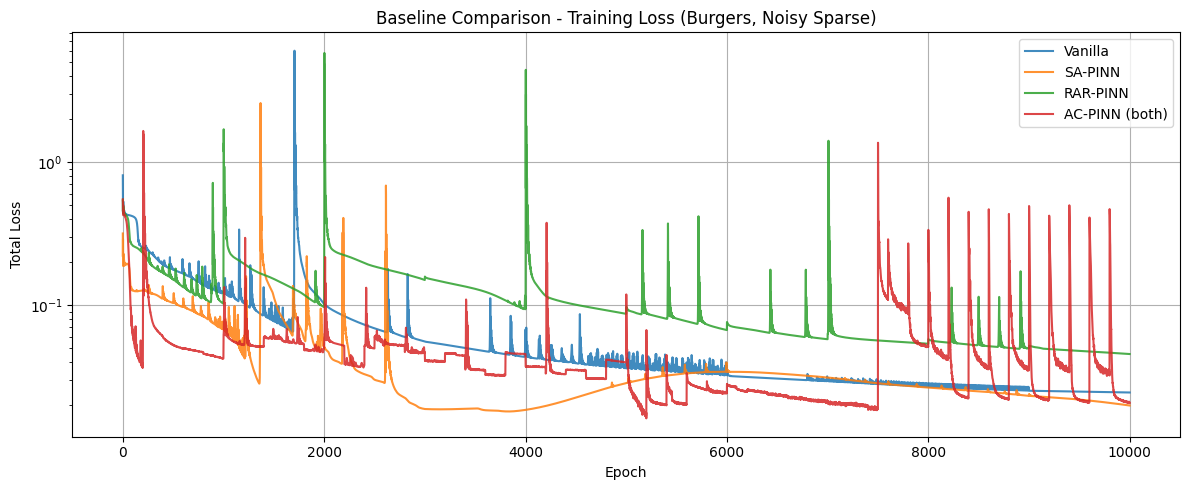

In [6]:
plt.figure(figsize=(12, 5))
for h, lbl in zip([h1, h2, h3, h4],
                  ['Vanilla', 'SA-PINN', 'RAR-PINN', 'AC-PINN (both)']):
    plt.plot(h['total'], label=lbl, alpha=0.85)
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Total Loss')
plt.title('Baseline Comparison - Training Loss (Burgers, Noisy Sparse)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES+'baselines_training_loss.png', dpi=150)
plt.show()


## Benchmark Table - Rel L2, MAE, RMSE vs FDM Ground Truth

Final accuracy of all 4 models against the finite-difference reference
solution.

In [7]:
models = [
    ('Vanilla PINN',    m1),
    ('SA-PINN',         m2),
    ('RAR-PINN',        m3),
    ('AC-PINN (both)',  m4),
]

bench = Benchmark(fdm, nx=200, nt=100)
for name, model in models:
    bench.add(name, model)
bench.run()

baseline_metrics = bench.compare_metrics()
save_metrics(baseline_metrics, RESULTS+'baselines_metrics.npy')


  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.551290   1.884907   0.111948   0.335275
  SA-PINN                     0.412468   1.855431   0.081445   0.250848
  RAR-PINN                    0.417254   1.543093   0.119155   0.253759
  AC-PINN (both)              0.559130   0.848015   0.274450   0.340043
Saved: ../results/burgers/baselines_metrics.npy


## Visual Comparison

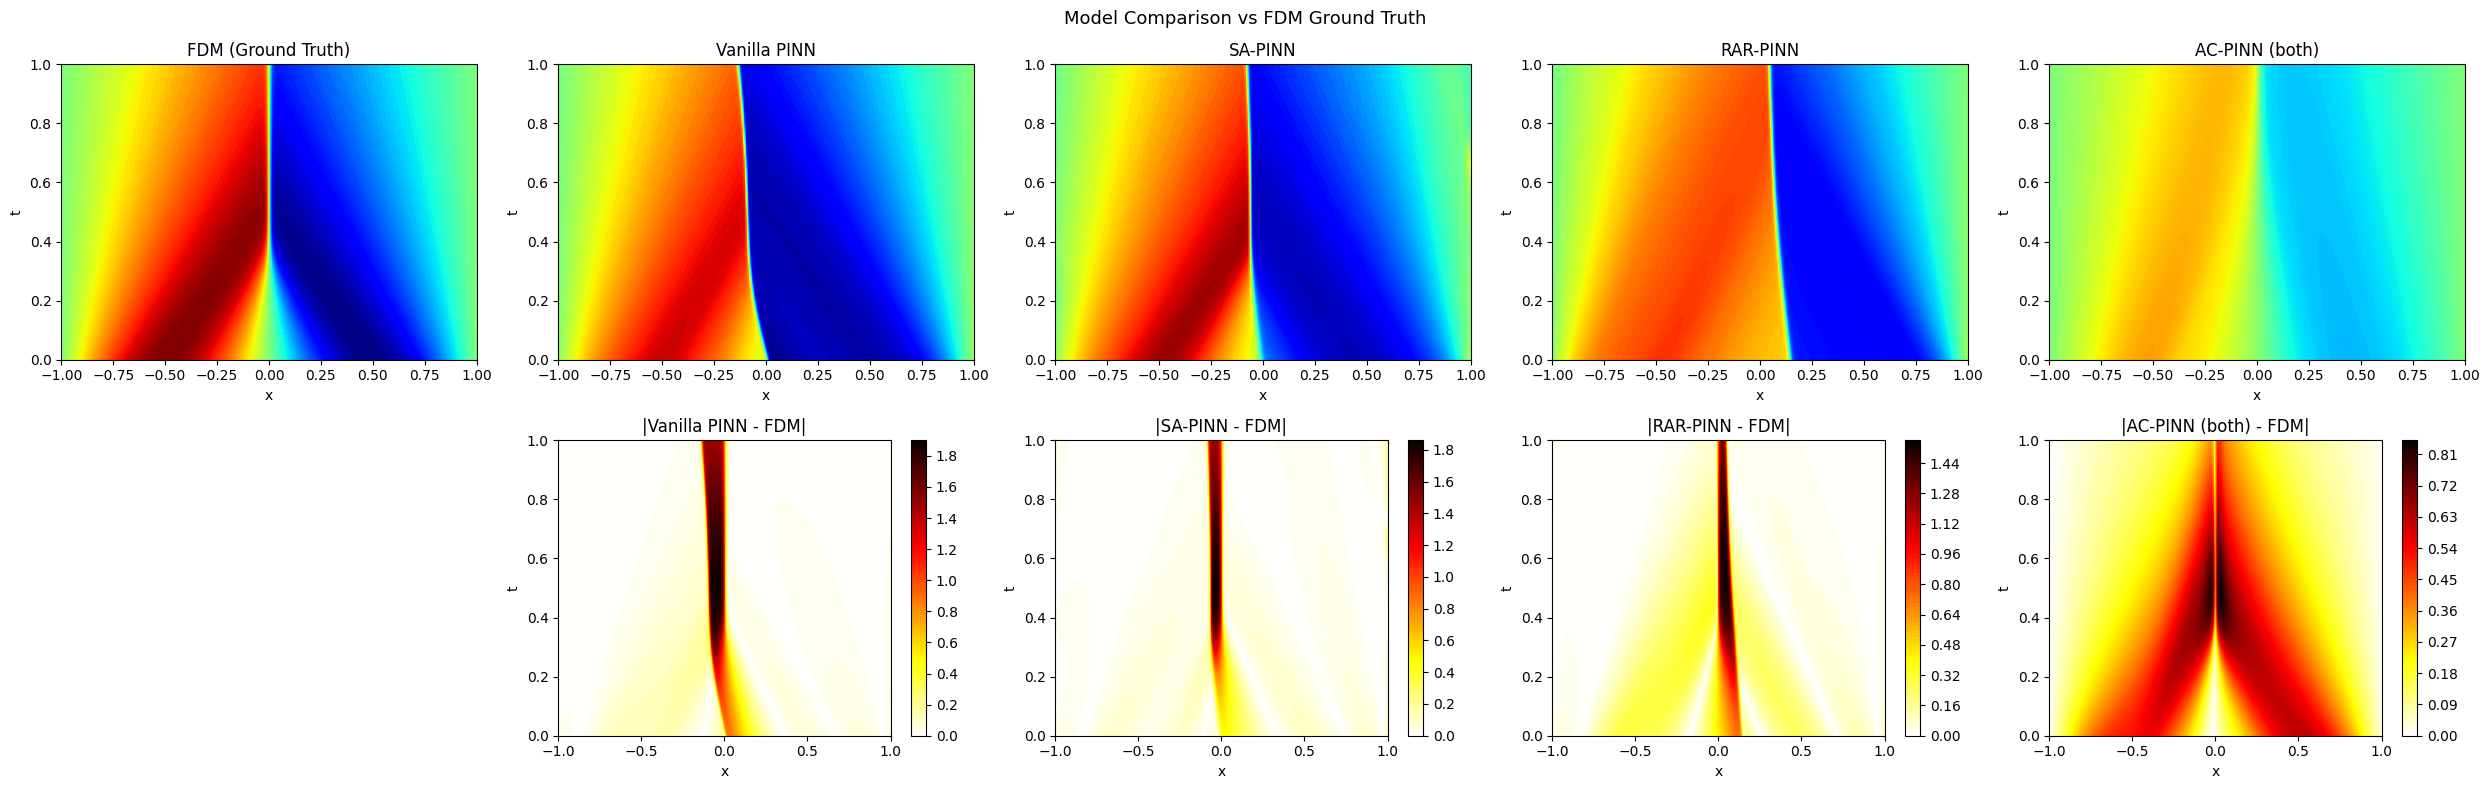

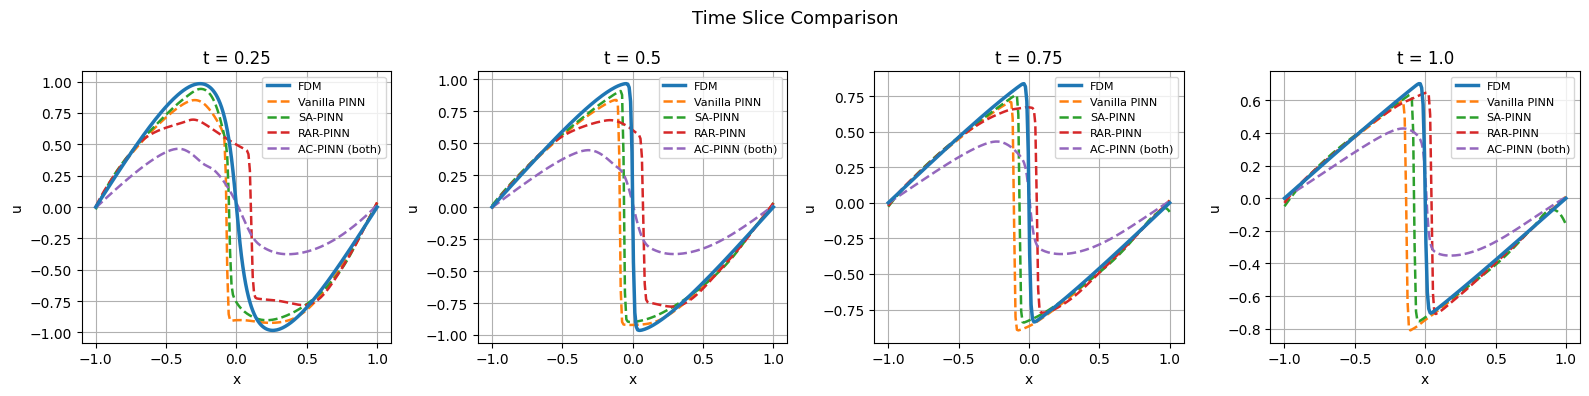

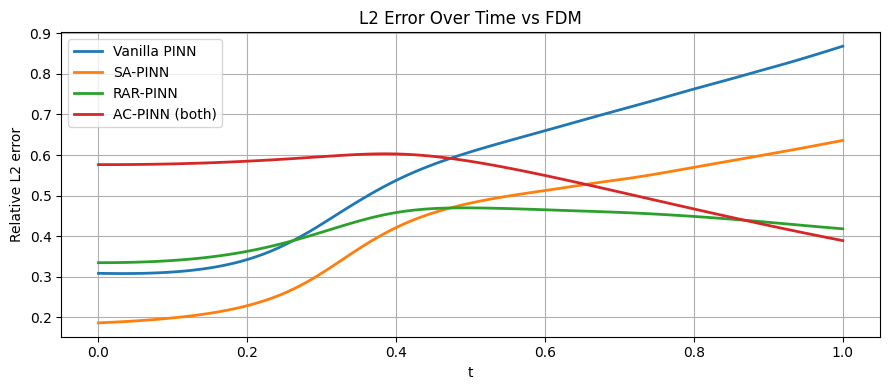

Baseline comparison complete.


In [8]:
bench.plot_comparison(save_path=FIGURES+'baselines_comparison.png')
bench.plot_time_slices(save_path=FIGURES+'baselines_time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'baselines_error_over_time.png')
print('Baseline comparison complete.')
